# 1. Задача №1. Подготовка набора данных и предварительный анализ (EDA)

## 1.1 Описание

### 1.1.1 Постановка задачи и анализ предметной области

**Задача** Подготовка собственного набора данных и проведение его предварительного анализа
- Выбрать набора данных из предложенных или согласовать набора данных с преподавателем.
- Провести анализ предметной задачи (горизонт прогнозирования, необходимость глобальных моделей, он-лайн\офлайн, метрики и тд)
Представить набора данных в машино-читаемом виде (pandas) и проведение его базового анализа (пропуски, типы данных, задание временных меток и т.д.)
- Провести EDA, включая анализ модели ВР и ее особенностей (сезонность, сведение к стационарному, и тд).
- Оформить EDA результатов и сохранение подготовленных данных.

**Ожидаемый результат:** описание ВР, EDA, постановка задачи, подготовленный к анализу ВР, отчет по EDA.

### 1.1.2 Описание набора данных

Был выбран датасет из примеров преподавателя по ссылке https://github.com/MVRonkin/TimeSeriesCourse/tree/main/OLD%20Versions/2026/datasets, а именно датасет по дорожному трафик

Краткие характеристики датасета:
- **Источник данных**: Исторические логи фиксации трафика на 4 различных перекрестках (Junction).
- **Целевой признак (y)**: Количество транспортных средств (Vehicles), зафиксированное за расчетный час.
- **Временная метка (ds)**: Дата и время фиксации с часовой дискретностью (Hourly).
- **Особенность структуры**: Набор данных содержит 4 параллельных временных ряда, объединенных по идентификатору перекрестка.

### 1.1.3 Анализ предметной задачи

- **Горизонт прогнозирования (H)**: 24 часа (прогноз на сутки вперед для оперативного планирования работы светофоров и дорожных служб).

- **Необходимость глобальных моделей**: Высокая. Поскольку перекрестки находятся в рамках одной городской транспортной системы, паттерны движения на них взаимосвязаны. Использование глобальных моделей (обучающихся на всех рядах сразу) потенциально эффективнее изолированных локальных моделей.

- **Режим работы**: Офлайн (модель обучается на собранном историческом пакете данных).

Метрики оценки:

- MAE (Mean Absolute Error) — показывает среднюю абсолютную ошибку в реальном количестве автомобилей, легко интерпретируется.

- RMSE (Root Mean Squared Error) — чувствительна к крупным выбросам и сильнее штрафует модель за критические промахи в пиковые часы.

## 1.2 Решение

In [12]:
# Импорт для Задачи №1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

In [13]:
# Загрузка данных c Гита и предпросмотр данных
url = "https://raw.githubusercontent.com/Hracc/ts-analysis/main/dataset/traffic.csv"
df = pd.read_csv(url)

df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [14]:
# Анализ датасета
print(" Информация о датасете ")
df.info()

print("\n Количество пропусков ")
print(df.isnull().sum())

 Информация о датасете 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

 Количество пропусков 
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


In [15]:
# Форматирование датасета для дальнейших задач
df = df.rename(columns={
    'Junction': 'unique_id',
    'DateTime': 'ds',
    'Vehicles': 'y'
})

df['ds'] = pd.to_datetime(df['ds'])

df = df[['unique_id', 'ds', 'y']]

print("\n Данные после приведения к стандарту ")
print(df.head())


 Данные после приведения к стандарту 
   unique_id                  ds   y
0          1 2015-11-01 00:00:00  15
1          1 2015-11-01 01:00:00  13
2          1 2015-11-01 02:00:00  10
3          1 2015-11-01 03:00:00   7
4          1 2015-11-01 04:00:00   9


In [16]:
print("Анализ доступных периодов по каждому перекрестку: ")
for j in df['unique_id'].unique():
    subset = df[df['unique_id'] == j]
    print(f"Перекресток {j}: с {subset['ds'].min()} по {subset['ds'].max()} | Всего точек: {len(subset)}")

Анализ доступных периодов по каждому перекрестку: 
Перекресток 1: с 2015-11-01 00:00:00 по 2017-06-30 23:00:00 | Всего точек: 14592
Перекресток 2: с 2015-11-01 00:00:00 по 2017-06-30 23:00:00 | Всего точек: 14592
Перекресток 3: с 2015-11-01 00:00:00 по 2017-06-30 23:00:00 | Всего точек: 14592
Перекресток 4: с 2017-01-01 00:00:00 по 2017-06-30 23:00:00 | Всего точек: 4344


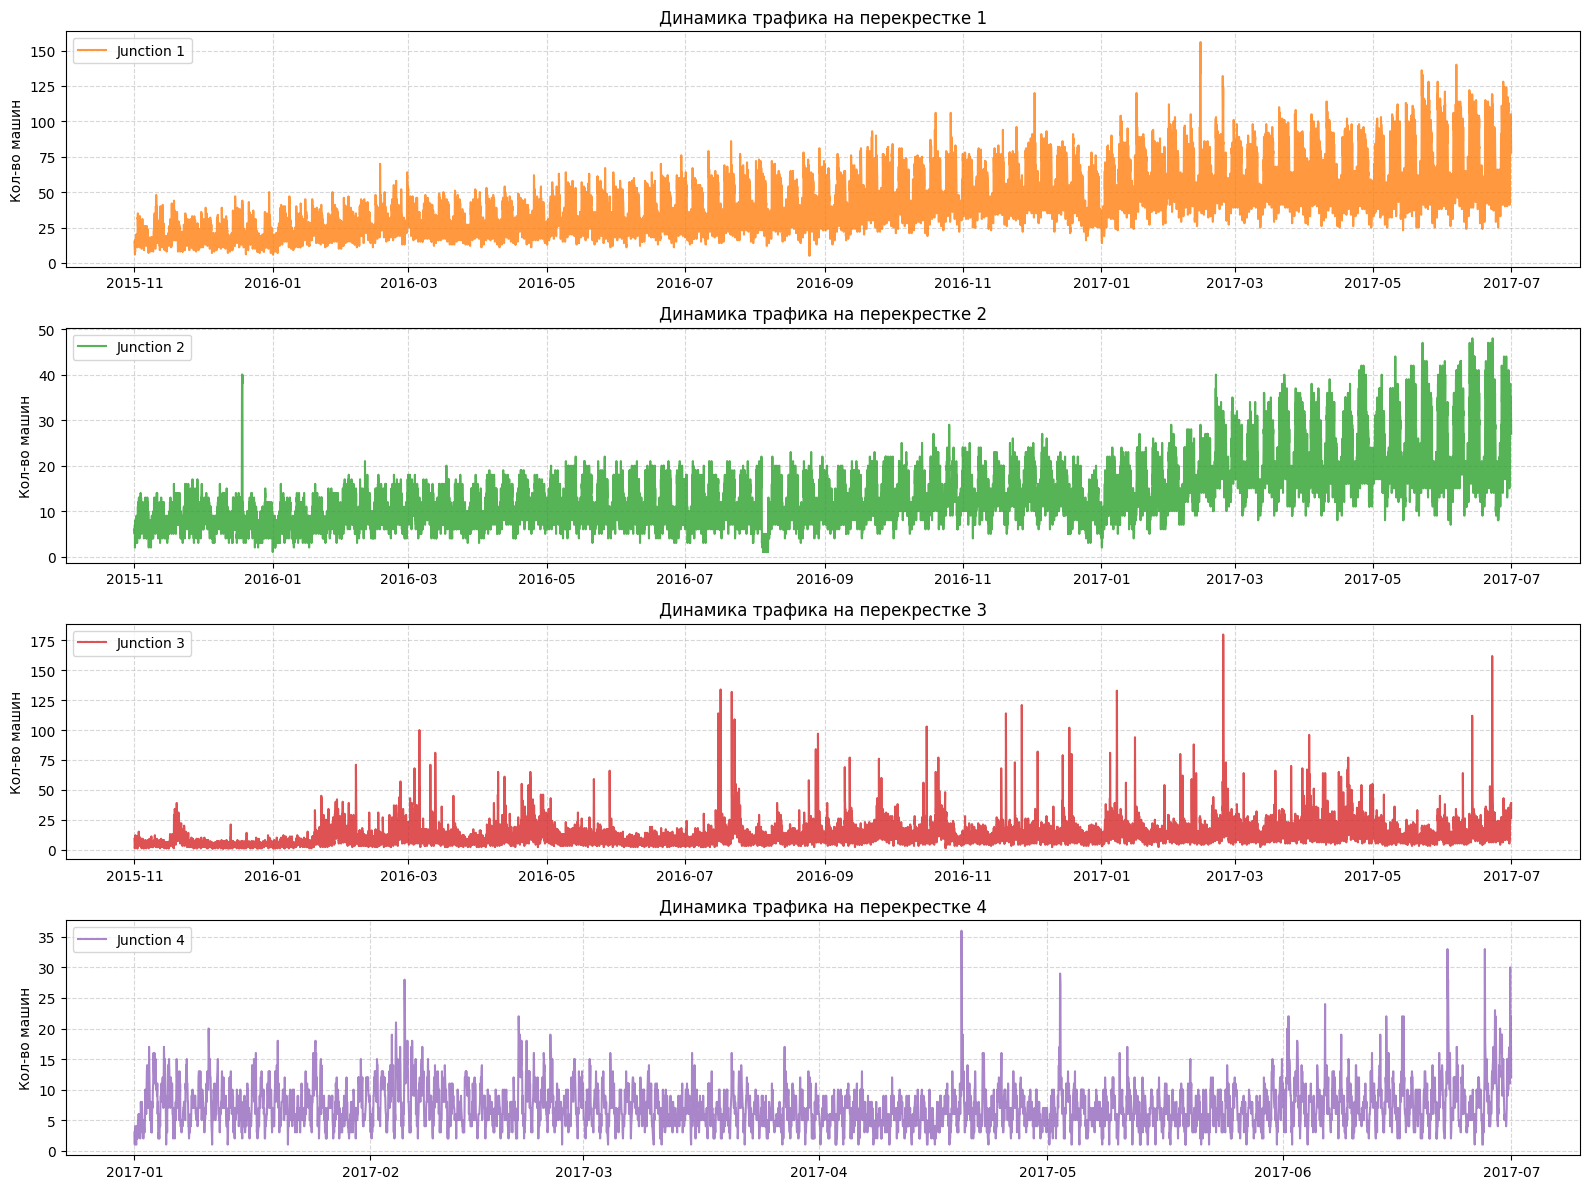

In [17]:
plt.figure(figsize=(16, 12))

for i, j in enumerate(df['unique_id'].unique(), 1):
    plt.subplot(4, 1, i)
    subset = df[df['unique_id'] == j]
    plt.plot(subset['ds'], subset['y'], label=f'Junction {j}', color=f'C{i}', alpha=0.8)
    plt.title(f'Динамика трафика на перекрестке {j}', fontsize=12)
    plt.ylabel('Кол-во машин')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
print(" Результаты теста Дики-Фуллера ")
for j in df['unique_id'].unique():
    subset = df[df['unique_id'] == j]
    result = adfuller(subset['y'])
    print(f"Перекресток {j}:")
    print(f"  Статистика теста: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.5f}")
    if result[1] < 0.05:
        print("  Вывод: Ряд стационарный (отклоняем нулевую гипотезу)")
    else:
        print("  Вывод: Ряд НЕстационарный (есть тренд или нестационарная структура)")
    print()

 Результаты теста Дики-Фуллера 
Перекресток 1:
  Статистика теста: -7.1481
  p-value: 0.00000
  Вывод: Ряд стационарный (отклоняем нулевую гипотезу)
----------------------------------------
Перекресток 2:
  Статистика теста: -8.0411
  p-value: 0.00000
  Вывод: Ряд стационарный (отклоняем нулевую гипотезу)
----------------------------------------
Перекресток 3:
  Статистика теста: -8.2366
  p-value: 0.00000
  Вывод: Ряд стационарный (отклоняем нулевую гипотезу)
----------------------------------------
Перекресток 4:
  Статистика теста: -6.7267
  p-value: 0.00000
  Вывод: Ряд стационарный (отклоняем нулевую гипотезу)
----------------------------------------


## 1.3 Выводы по Задаче №1

Во время выполнения задачи было обнаружено и сделаны такие части, как:
1. **Исходный набор данных** содержит 48 120 часовых наблюдений. При анализе данных не были обнаружены пропуски и скрытые дефекты.

2. **Колонки были заранее переименованы** и приведены к каноничному стандарту экосистемы Nixtla (unique_id, ds, y), а текстовый формат времени преобразован в тип datetime64.

3. **В ходе анализа выявлена разная длина истории наблюдений по перекресткам.** Ряды Перекрестков 1, 2 и 3 являются полными и содержат по 14 592 точки. Наблюдения по Перекрестку 4 начинаются значительно позже — только с 1 января 2017 года, из-за чего этот ряд более чем в 3 раза короче остальных. Данный дисбаланс необходимо учитывать при настройке глубины истории для глобальных моделей.

4. **Инфраструктурные особенности и паттерны (по графикам):**

    - *Перекресток 1*: Является самым нагруженным транспортным узлом. Он демонстрирует мощный нелинейный восходящий тренд: средний поток вырос с 20–40 машин в конце 2015 года до пиковых значений в 120–150+ машин в час к лету 2017 года.

    - *Перекресток 2*: Также имеет стабильный восходящий тренд, но масштаб трафика скромнее. Средние часовые значения за исследуемый период увеличились с 10–15 до 30–40 автомобилей, а максимальные пиковые выбросы достигают 80–90 машин.

    - *Перекресток 3*: Самый стабильный и предсказуемый объект. На протяжении всех 20 месяцев график идет равномерной полосой без видимого восходящего или нисходящего тренда. Трафик зажат в постоянном коридоре и колеблется в пределах 15–40 машин, редко превышая планку в 50 единиц.

    - *Перекресток 4*: Самый слабозагруженный участок с потоком преимущественно до 20 машин в час. Из-за малого количества транспорта график выглядит разреженным (высокая дискретность). При этом ближе к лету 2017 года наметился слабый локальный тренд на рост.

    - *Общая сезонность*: На графиках всех четырех перекрестков прослеживается плотная цикличная «гребенка», особенно на 1 и 2 перекрестке. Это визуально подтверждает наличие внутрисуточной сезонности по типу дневных час пиков и ночных спад и недельной активности, например, различия в поведении трафика между буднями и выходными днями.

5. **Расширенный тест Дики-Фуллера (ADF)** для всех четырех рядов вернул значение p-value =0.00000. Сама статистика теста находится в диапазоне от -6.72 до -8.23. Это отклоняет нулевую гипотезу о наличии единичного корня и определяет ряды как стационарные (постоянство дисперсии). Однако, из-за сильного дрейфа математического ожидания вверх ряды нестационарны. Для успешного применения линейных статистических моделей в Задаче №2 может потребоваться операция взятия разностей.

# 2. Задача №2. Освоение наиболее популярных инструментов АВР, и обоснованный выбор методов статистических методов анализа ВР

## 2.1 Описание

- Изучить фреймворк statsforecast
- Изучить основные методы предсказания ВР в фреймворке (ARIMA, ETS, Theta prophet) в форматах ручного и автоподбора параметров.
- Провести обоснованный выбор (бектестинг, вероятностное предсказание, анализ остатков и другие техники) для выбранного временного ряда

**Ожидаемый результат:** обоснованное сравнение не менее 5 методов предсказания ВР, включая ручной и автоматической режимах.

## 2.2 Решение

## 2.3 Выводы по Задаче №2

# 3. Задача №3. Обоснованный выбор методов data-driven анализа ВР (ML, DL) и оценка его точности и надежности.

## 3.1 Описание

- Изучить фреймворки mlforecast, neural forecast
- Изучить особенности feature engineering для временных рядов (mlforecast)
- Провести исследование с целью обоснованного выбора и настройка методов.

**Ожидаемый результат:** обоснованное сравнение не менее 3 методов машинного обучения и 3 методов на основе глубокого обучения для предсказания ВР.

## 3.2 Решение

## 3.3 Выводы по Задаче №3

# 4. Задача №4 Подготовка пайплайна решения задачи предсказания ВР, а также подготовка отчета исследования ВР.

## 4.1 Описание

- Подгодовить пайплайн решения задачи предсказания ВР.
- Обоснованнать настройку пайплайна и выбор его компонент.
- Провести статистическое тестирование пайплайна ВР и тестирование на - производительность.
- Подготовить отчет об исследовании ВР

**Ожидаемый результат:** пайплайн, результаты его тестирования и отчет об исследовании ВР.

## 4.2 Решение

## 4.3 Выводы по Задаче №4